# Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report

# Dataset

In [ ]:
# connect drive with colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import dataset
df = pd.read_csv('/content/drive/MyDrive/DIBIMBING.ID/Assignment 37 - AI Churn Prediction & Business Strategy/bank_churn_data.csv')

In [ ]:
# load dataset
df.head(10)

,user_id,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,...,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,...,1,2,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311
6,810347208,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,...,1,3,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066
7,818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,...,2,2,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,...,2,0,22352.0,2517,19835.0,3.355,1350,24,1.182,0.113
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,...,3,3,11656.0,1677,9979.0,1.524,1441,32,0.882,0.144


In [ ]:
# data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10127 non-null  int64  
 1   attrition_flag            10127 non-null  object 
 2   customer_age              10127 non-null  int64  
 3   gender                    10127 non-null  object 
 4   dependent_count           10127 non-null  int64  
 5   education_level           10127 non-null  object 
 6   marital_status            10127 non-null  object 
 7   income_category           10127 non-null  object 
 8   card_category             10127 non-null  object 
 9   months_on_book            10127 non-null  int64  
 10  total_relationship_count  10127 non-null  int64  
 11  months_inactive_12_mon    10127 non-null  int64  
 12  contacts_count_12_mon     10127 non-null  int64  
 13  credit_limit              10127 non-null  float64
 14  total_

Keterangan Data :
1. user_id : nomor unik yang dimiliki setiap pelanggan sebagai identifikasi data pelanggan.
2. attrition_flag : aktivitas pelanggan, dengan 'Attrited Customer' sebagai pelanggan yang telah menutup akun dan 'Existing Customer' sebagai pelanggan yang masih berlangganan.
3. customer_age : Usia pelanggan.
4. gender : Jenis kelamin pelanggan, dengan M sebagai Male/Laki-laki dan F sebagai Female/Perempuan.
5. dependent_count : Jumlah tanggungan yang dimiliki pelanggan.
6. education_level : Tingkat pendidikan pelanggan.
7. marital_status : Status pernikahan pelanggan.
8. income_category : Pendapatan Pelanggan.
9. card_category : Jenis kartu yang dimiliki pelanggan.
10. months_on_book : Berapa bulan pelanggan telah menjadi nasabah.
11. total_relationship_count : Jumlah produk bank yang telah dimiliki pelanggan.
12. months_inactive_12_mon : Berapa bulan pelanggan tidak aktif dalam setahun terakhir.
13. contacts_count_12_mon : Berapa banyak kontak dengan pelanggan dalam setahun terakhir.
14. credit_limit : Limit kartu kredit.
15. total_revolving_bal : Jumlah Revolving Balance pada kartu kredit pelanggan.  
16. avg_open_to_buy : Rata-rata jumlah kredit yang tersisa dan dapat digunakan oleh pelanggan dalam setahun terakhir.
17. total_amt_chng_q4_q1 : Perubahan jumlah transaksi pelanggan (Q4 dibandingkan dengan Q1, amount).
18. total_trans_amt : Total jumlah transaksi pelanggan setahun terakhir (amount).
19. total_trans_ct : Total jumlah transaksi pelanggan setahun terakhir (count).
20. total_ct_chng_q4_q1 : Perubahan jumlah transaksi pelanggan (Q4 dibandingkan dengan Q1, count).
21. avg_utilization_ratio : Rata-rata rasio penggunaan kartu pelanggan.

Analisis berdasarkan informasi data:
1. Dataset ini digunakan untuk mempelajari pola perilaku pelanggan, memiliki 21 kolom dengan 10127 baris.
2. Missing value tidak ditemukan berdasarkan informasi data diatas dikarenakan seluruh kolom memiliki jumlah baris 10127, namun tetap harus melakukan analisis missing value lanjutan ditakutkan adanya missing value implisit.
3. Terdapat 3 tipe data : integer, float, dan object.


# Business Understanding

## Churn Rate Total

In [ ]:
# cek data apa saja di kolom attrition_flag
df['attrition_flag'].unique()

array(['Existing Customer', 'Attrited Customer'], dtype=object)

In [ ]:
# hanya mengambil data Attirited Customer
persentase_churn_rate = (df['attrition_flag'] == 'Attrited Customer').mean()
total_churn_rate = df['attrition_flag'].value_counts()['Attrited Customer']

# hasil
print(f"Persentase Churn Rate: {persentase_churn_rate*100:.2f}%")
print(f"Jumlah Churn Rate: {total_churn_rate}")

Persentase Churn Rate: 16.07%
Jumlah Churn Rate: 1627


Churn Rate menunjukan jumlah pelanggan yang berhenti langganan, pada data ini ditunjukan melalui kolom Attrition_Flag. Churn Rate disini, dihitu berdasarkan jumlah pelanggan yang berhenti berlangganan per jumlah total pelanggan sehingga didapatkan 16,07% atau sebanyak 1627 pelanggan.

Jika churn rate sekitar 16,07%, maka dapat diartikan bahwa dari setiap 100 nasabah, sekitar 16 orang berhenti menggunakan kartu kredit.

## Dampak churn terhadap revenue

In [ ]:
# revenue pelanggan churn
churn_revenue = df[df['attrition_flag']=='Attrited Customer']['total_trans_amt'].sum()

# revenue pelanggan tidak churn
non_churn_revenue = df[df['attrition_flag']=='Existing Customer']['total_trans_amt'].sum()

# hasil
print("Estimated Lost Revenue:", churn_revenue)
print("Estimated Net Revenue:", non_churn_revenue)

Estimated Lost Revenue: 5035607
Estimated Net Revenue: 39564575


Revenue adalah total seluruh pendapatan baik yang kotor maupun yang bersih masih menjadi satu. Oleh karena itu untuk melihat dampak churn terhadap revenue dapat dilihat berdasarkan kolom total_trans_amt atau total_trans_ct, namun disini kita mengggunakan total_trans_amt diakrenakan lebih terlihat berapa total uang yang digunakan.

Dampak churn terhadap Revenue adalah semakin tinggi pelanggan churn, maka bank akan mengalami penurunan revenue yang cukup tinggi.

## Metrik untuk Evaluasi Model

Metrik utama yang digunakan adalah recall, karena recall dapat memberikan hasil prediksi churn yang lebih baik jika dibandingkan dengan akurasi, karena akurasi lebih rentan salah.

## Risiko Bisnis jika salah prediksi

1. Jika terdapat pelanggan churn, namun model tidak memprediksi pelanggan churn, maka bank akan kehilangan kesempatan untuk memberikan pelanggan penawaran khusus agar pelanggan bertahan, sehingga peluang kehilangan pelanggan juga besar.
2. Jika terdapat pelanggan tidak churn, namun model memprediksi churn, maka bank akan mengalami kerugian karna memberikan penawaran yang tidak tepat sehingga biaya marketing yang dikeluarkan lebih banyak.



# Exploratory Data Analysis (EDA)

In [ ]:
# membuat data copy untuk analisis EDA
A = df.copy()

## Analisis churn rate variabel kategorikal

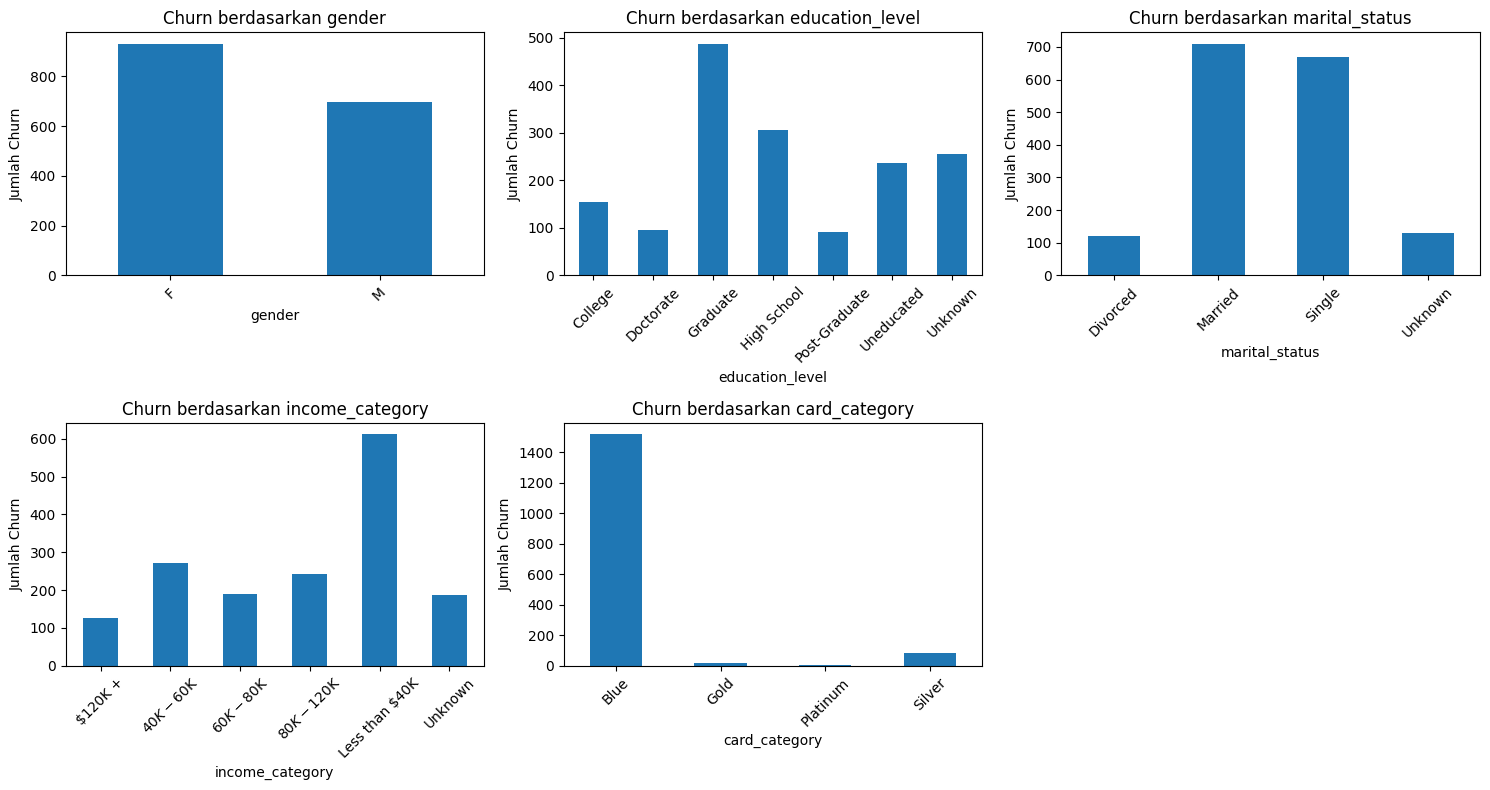

In [ ]:
# memisahkan varalbel kategorik
categorical = A.select_dtypes(include=['object'])

# drop attrited flag
categorical = categorical.drop('attrition_flag', axis=1)

# visualisasi data kategorik
plt.figure(figsize=(15,8))

for i, col in enumerate(categorical):

    plt.subplot(2,3,i+1)

    churn_cat = pd.crosstab(A[col], A['attrition_flag'])['Attrited Customer']
    churn_cat.plot(kind='bar', ax=plt.gca())

    plt.title(f"Churn berdasarkan {col}")
    plt.ylabel("Jumlah Churn")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

1. Gender : Pelanggan dengan jenis kelamin perempuan cenderung lebih banyak yang churn dibandingkan dengan yang laki-laki walau perbedaannya tidak terlalu jauh, dimana pelanggan perempuan cenderung lebih suka memilih dan membandingkan mana yang lebih menarik penawaran dan benefitnya.
2. Education Level : Pelanggan dengan level education Graduate memiliki chur yang tertinggi jika dibandingkan dengan yang lain.
3. Marital Status : Pelanggan yang sudah menikah dan single menunjukan churn tertinggi, hal ini menunjukan bahwa tidak terlalu berpengaruh status pernikahan terhadap churn.
4. Income : Pelanggan dengan income dibawah $40 memiliki churn tertinggi, dimana pelanggan dengan pendapatan rendah lebih sensitif terhadap biaya layanan atau lebih mudah berpindah ke kompetitor yang menawarkan keuntungan lebih baik.
5. Card Category : Pelanggan dengan Kartu berwarna biru memiliki churn tertinggi, dimana pelanggan dengan kartu yang paling dasar cenderung memiliki penawaran yang lebih rendah jika dibandingkan dengan pelanggan dengan kartu yang lainnya, sehingga ketika ada penawaran yang lebih baik pelanggan akan lebih mudah berpindah.

## Analisis churn variabel numerik

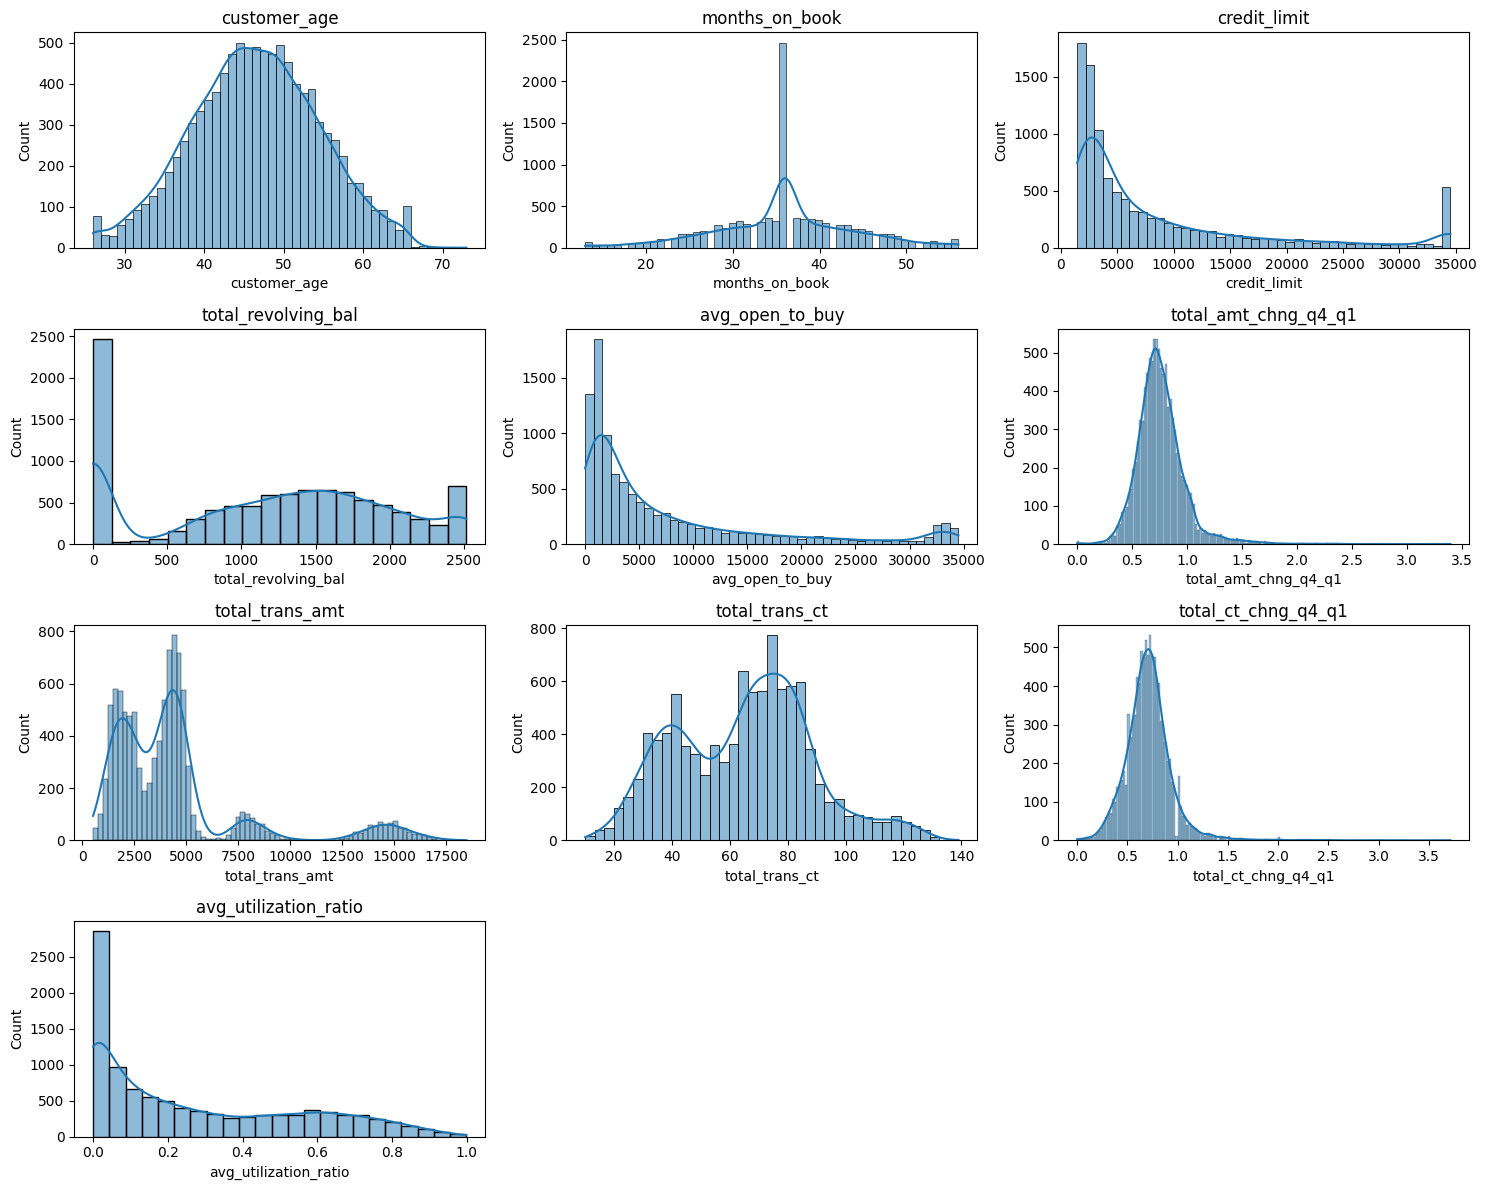

In [ ]:
# filter data churn
churn = A[A['attrition_flag'] == 'Attrited Customer']

# memisahkan variabel numerik
numerical = A.select_dtypes(include=['int64', 'float64'])

# pisahkan numerik continous
numerical_continuous = numerical.drop(columns=[
    'user_id',
    'dependent_count',
    'total_relationship_count',
    'months_inactive_12_mon',
    'contacts_count_12_mon'
])

# visualisasi data numerik
plt.figure(figsize=(15,12))

for i, col in enumerate(numerical_continuous):

    plt.subplot(4,3,i+1)
    sns.histplot(data=A, x=col, kde=True)

    plt.title(col)

plt.tight_layout()
plt.show()

1. Customer Age : Distribusi terlihat normal, churn paling banyak berada pada kisaran 40 hingga 55 tahun, dimana pada usia ini biasanya memiliki kebutuhan finansial yang lebih banyak sehingga mudah pindah ke kompetitor yang dianggap lebih menguntungkan.
2. Months on Book : Distribusi Normal, Churn paling banyak berada pada kisaran 34-37 bulan, dimana setelah kurang lebih 3 tahun, sebagian pelanggan kemungkinan melakukan evaluasi dan banyak kompetitor yang memiliki penawaran yang lebih menarik dan lebih baik.
3. Credit Limit : Distribusi right-skewed, churn paling banyak berada pada limit yang rendah atau sekitar 1000-5000, dimana limit yang rendah biasanya tidak memiliki banyak keuntungan seperti limit yang lebih tinggi, sehingga elanggan merasa kurang mendapat benefitnya.
4. Total Revolving Balance : Churn paling banyak terdapat pada pelanggan yang memiliki saldo sangat rendah atau mendekati nol, meskipun ada sebagian yang memiliki saldo sekitar 2500, dimana pelanggan churn cenderung tidak aktif menggunakan fasilitas kredit secara intensif.
5. Average Open to Buy : Churn paling banyak terdapat pada pelanggan yang memiliki sisa limit kredit yang cukup besar, dimana penggunaan limit yang rendah menunjukkan tingkat keterlibatan pelanggan terhadap produk kartu kredit juga rendah.
6. Total Amount Change Q4 to Q1 : Churn paling banyak berada pada sekitar 0.6–0.8, dimana penurunan aktivitas transaksi dapat menjadi indikator awal pelanggan mulai meninggalkan layanan.
7. Total Transaction Amount : Churn paling banyak berada pada pelanggan yang memiliki nilai transaksi rendah hingga menengah, yaitu 2500-5000, dimana aktivitas transaksi yang rendah menunjukkan rendahnya keterlibatan pelanggan terhadap layanan bank.
8. Total Transaction Count : Churn palingbanyak berada pada pelanggan yang memiliki frekuensi transaksi sebanyak 40-80, dimana aktivitas transaksi yang rendah menunjukkan rendahnya keterlibatan pelanggan terhadap layanan bank.
9. Total Count Change Q4 to Q1 : Churn paling banyak berada pada sekitar 0.6–0.8, dimana penurunan aktivitas transaksi dapat menjadi indikator awal pelanggan mulai meninggalkan layanan.
10. Average Utilization Ratio : Churn palingbanyak berada pada pelanggan yang memiliki rata-rata utilization ratio rendah, di bawah 0.2, dimana rasio penggunaan kredit yang rendah menunjukkan bahwa kartu kredit tidak menjadi alat pembayaran utama bagi pelanggan tersebut.

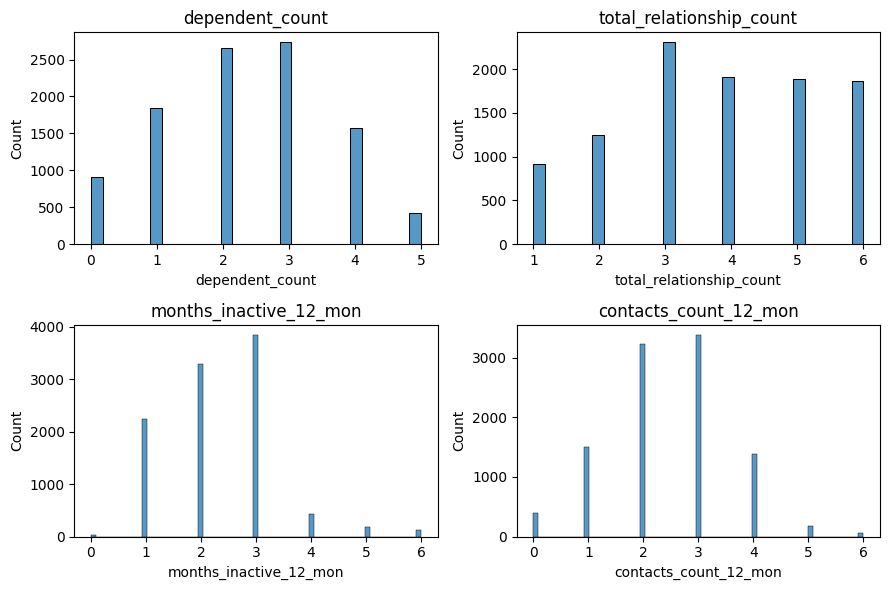

In [ ]:
# pisahkan numerik kategorik
numerical_categoric = numerical.drop(columns=[
    'user_id',
    'customer_age',
    'credit_limit',
    'total_revolving_bal',
    'avg_open_to_buy',
    'total_trans_amt',
    'total_trans_ct',
    'total_amt_chng_q4_q1',
    'total_ct_chng_q4_q1',
    'avg_utilization_ratio',
    'months_on_book'
])

# visualisasi data numerik
plt.figure(figsize=(9,6))

for i, col in enumerate(numerical_categoric):

    plt.subplot(2,2,i+1)
    sns.histplot(data=A, x=col)

    plt.title(col)

plt.tight_layout()
plt.show()

1. Dependent Count : Churn paling banyak berada pada pelanggan dengan jumlah tanggungan menengah, yaitu 2-3.
2. Total Relationship Count : Churn paling banyak berada pada pelanggan yang memiliki sekitar 3–5 hubungan produk dengan bank.
3. Months Inactive (12 Months) : Churn paling banyak berada oada pelangggan yang 2–3 bulan tidak aktif dalam 12 bulan terakhir.
4. Contacts Count (12 Months) : Churn paling banyak berada pada planggan yang 2–3 kali melakukan kontak dengan bank dalam setahun.

## Identifikasi customer dengan risiko churn tertinggi

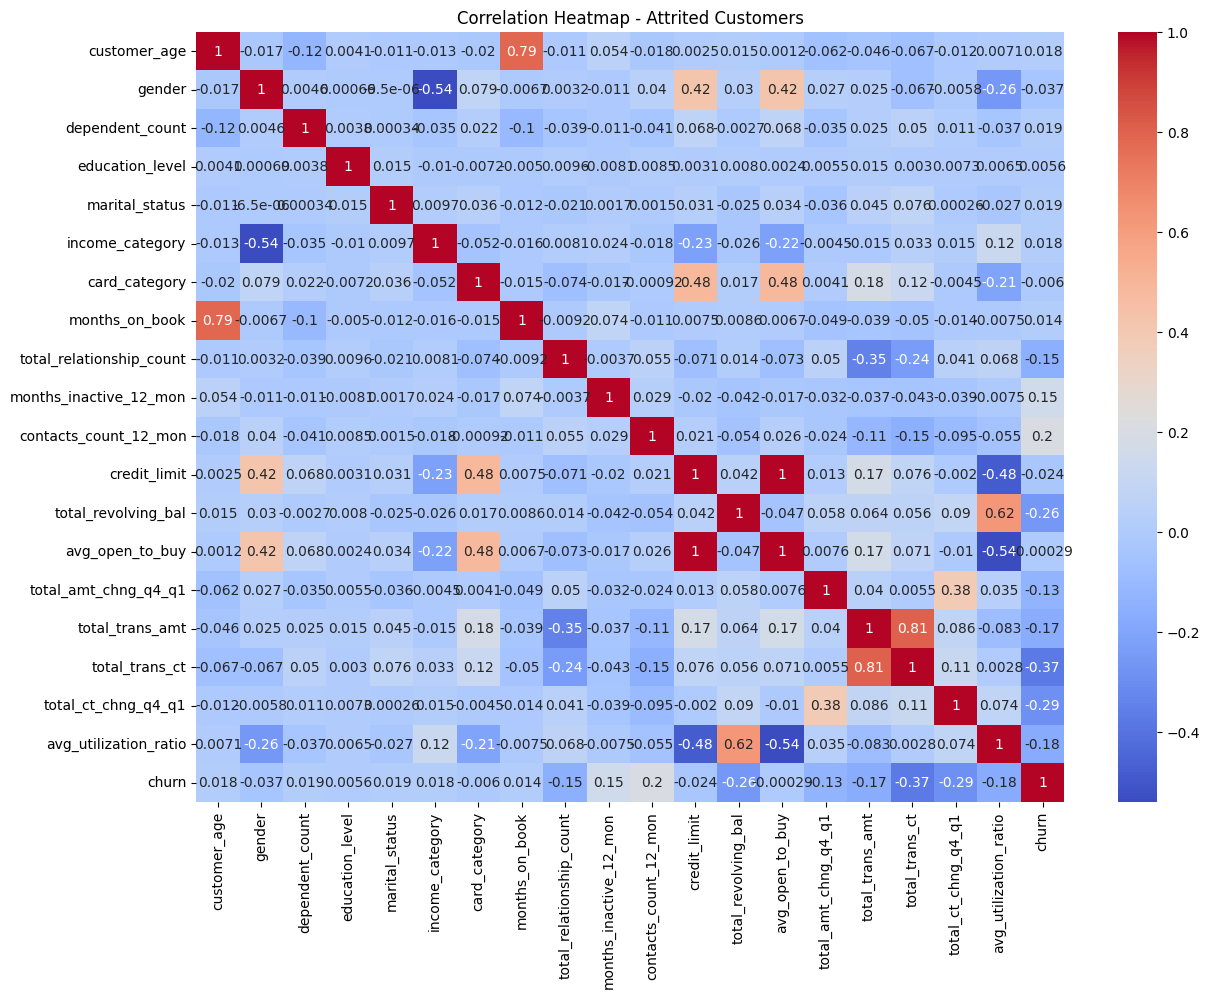

In [ ]:
# encode churn
A['churn'] = A['attrition_flag'].map({
    'Existing Customer':0,
    'Attrited Customer':1
})

# drop id
B = A.drop(columns=['user_id','attrition_flag'])

# encode data kategorik
for col in B.select_dtypes(include='object'):
    B[col] = B[col].astype('category').cat.codes

# hitung korelasi
corr = B.corr()

# visualisasi
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True
)

plt.title("Correlation Heatmap - Attrited Customers")
plt.show()

Jika dilihat berdasarkan heatmap, maka yang pelanggan yang memiliki risiko churn tertinggi adalah yang
1. Memiliki frekuensi transaksi sebanyak 40-80, dimana aktivitas transaksi yang rendah.
2. Memiliki Total Count Change Q4 to Q1 berada pada sekitar 0.6–0.8, dimana terdapat penurunan aktivitas transaksi.
3. Memiliki saldo sangat rendah atau mendekati nol.
4. 2–3 kali melakukan kontak dengan bank dalam setahun.
5. Memiliki rata-rata utilization ratio rendah, di bawah 0.2.
6. Memiliki nilai transaksi rendah hingga menengah, yaitu 2500-5000.
7. Memiliki sekitar 3–5 hubungan produk dengan bank.
8. 2–3 kali melakukan kontak dengan bank dalam setahun.


yang memiliki korelasi paling kuat adalah kolom : total_trans_ct, total_ct_chng_q4_q1, total_revolving_bal, contacts_count_12_mon, avg_utilization_ratio, total_trans_amt, total_relationship_count, months_inactive_12_mon

# Pre Processing Data

In [ ]:
# copy data asli untuk proses preprocessing sampai akhir
# data di copy agar tidak mengubah data aslinya jika nanti diperlukan kembali
C = df.copy()

## Hapus Kolom

In [ ]:
# hapus user id
C = C.drop(columns=['user_id'])

## Missing Value

In [ ]:
C.isnull().sum()

,0
attrition_flag,0
customer_age,0
gender,0
dependent_count,0
education_level,0
marital_status,0
income_category,0
card_category,0
months_on_book,0
total_relationship_count,0


In [ ]:
# cek uknown
C.isin(['Unknown']).sum()

,0
attrition_flag,0
customer_age,0
gender,0
dependent_count,0
education_level,1519
marital_status,749
income_category,1112
card_category,0
months_on_book,0
total_relationship_count,0


In [ ]:
# cek bagian mana yang terdapat uknown
C[C.isin(['Unknown']).any(axis=1)]

,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
6,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,6,1,3,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066
7,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,2,2,2,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048
10,Existing Customer,42,M,5,Uneducated,Unknown,$120K +,Blue,31,5,3,2,6748.0,1467,5281.0,0.831,1201,42,0.680,0.217
11,Existing Customer,65,M,1,Unknown,Married,$40K - $60K,Blue,54,6,2,3,9095.0,1587,7508.0,1.433,1314,26,1.364,0.174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10101,Existing Customer,42,M,2,Graduate,Unknown,$40K - $60K,Blue,30,3,2,5,3735.0,1723,2012.0,0.595,14501,92,0.840,0.461
10118,Attrited Customer,50,M,1,Unknown,Unknown,$80K - $120K,Blue,36,6,3,4,9959.0,952,9007.0,0.825,10310,63,1.100,0.096
10119,Attrited Customer,55,F,3,Uneducated,Single,Unknown,Blue,47,4,3,3,14657.0,2517,12140.0,0.166,6009,53,0.514,0.172
10123,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511


secara explisit memang tidak terdapat missing value, namun secara implisit terdapat missing value pada beberapa variabel kategorik dengan kata 'uknown', namun keputusan yang diambil adalah dengan tidak menghampus atau mengimputasi, melainkan diperlakukan sebagai kategori tersendiri. Hal ini dilakukan karena nilai tersebut masih mengandung informasi mengenai kondisi data pelanggan yang tidak diketahui.

## Duplicates Data

In [ ]:
C.duplicated().sum()

np.int64(0)

## Encoding

In [ ]:
# encode target
C['attrition_flag'] = C['attrition_flag'].map({
    'Existing Customer':0,
    'Attrited Customer':1
})

In [ ]:
# pisahkan kolom kategorik
cat = C.select_dtypes(include=['object'])

# one hot encoding
C = pd.get_dummies(C, columns=cat.columns, drop_first=True)

In [ ]:
# cek apakah sudah berubah
C.head()

,attrition_flag,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,...,marital_status_Single,marital_status_Unknown,income_category_$40K - $60K,income_category_$60K - $80K,income_category_$80K - $120K,income_category_Less than $40K,income_category_Unknown,card_category_Gold,card_category_Platinum,card_category_Silver
0,0,45,3,39,5,1,3,12691.0,777,11914.0,...,False,False,False,True,False,False,False,False,False,False
1,0,49,5,44,6,1,2,8256.0,864,7392.0,...,True,False,False,False,False,True,False,False,False,False
2,0,51,3,36,4,1,0,3418.0,0,3418.0,...,False,False,False,False,True,False,False,False,False,False
3,0,40,4,34,3,4,1,3313.0,2517,796.0,...,False,True,False,False,False,True,False,False,False,False
4,0,40,3,21,5,1,0,4716.0,0,4716.0,...,False,False,False,True,False,False,False,False,False,False


ecoding dilakukan agar data dapat di proses lebih mudah menggunakan variabel numerik, adapun pemilihan encode berdasarkan :
1. Label Encoding pada target digunakan karena variabel target hanya memiliki dua kelas.
2. One Hot Encoding digunakan agar model tidak menganggap adanya hubungan urutan antar kategori.

## Split Data

In [ ]:
X = C.drop(columns=['attrition_flag'])
y = C['attrition_flag']

## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Dataset dibagi menjadi data training dan data testing untuk mengevaluasi performa model pada data yang belum pernah dilihat sebelumnya. Data Size 0.2 menjelaskan bahwa pada saat training menggunakan 80% data dan pada saat testing menggunakan 20% data sisanya.

## Transformasi Fitur

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling untuk menyamakan skala agar tidak ada perbedaan rentang nilai yang terlalu besar. Metode StandardScaler digunakan karena mampu mengubah distribusi data sehingga memiliki rata-rata (mean) mendekati 0 dan standar deviasi sebesar 1.

## Data Imbalance

In [ ]:
# cek data imbalance
y_train.value_counts()

,count
attrition_flag,
0,6799
1,1302


In [ ]:
# handling imbalance
# smote = SMOTE(random_state=42)

# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Pemodelan Machine Learning

## Logistic Regression

In [ ]:
# baseline logreg
logreg = LogisticRegression(
    max_iter=1000
)

model_logreg = logreg.fit(X_train_scaled, y_train)

In [ ]:
# tuning logreg
param_logreg = {
    'C':[0.01,0.1,1,10],
    'solver':['lbfgs','liblinear']
}

grid_logreg = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_logreg,
    cv=5,
    scoring='f1'
)

model_tuning_logreg = grid_logreg.fit(X_train_scaled, y_train)

best_logreg = grid_logreg.best_estimator_

## XGBoost

In [ ]:
# baseline XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

model_xgboost = xgb.fit(X_train, y_train)

In [ ]:
# Tuning XGBoost
param_xgb = {
    'n_estimators':[100,200],
    'max_depth':[3,6,10],
    'learning_rate':[0.01,0.1,0.2]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_xgb,
    cv=5,
    scoring='f1'
)

model_tuning_xgboost = grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

## Decision Tree

In [ ]:
# baseline Decision Tree
dt = DecisionTreeClassifier(random_state=42)

model_dt = dt.fit(X_train, y_train)

In [ ]:
# tuning decision tree
param_dt = {
    'max_depth':[5,10,20],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=5,
    scoring='f1'
)

model_tuning_dt = grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

## Random Forest

In [ ]:
# baseline rf
rf = RandomForestClassifier(random_state=42)

model_rf = rf.fit(X_train, y_train)

In [ ]:
# tuning rf
param_rf = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=5,
    scoring='f1'
)

model_tuning_rf = grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

# Evaluasi Model

## Best Model

In [ ]:
def evaluate_model_time(model, X_train, y_train, X_test, y_test):

    # waktu training
    start_train = time.time()
    model.fit(X_train, y_train)
    end_train = time.time()

    train_time = end_train - start_train

    # waktu prediksi
    start_test = time.time()
    y_pred_test = model.predict(X_test)
    end_test = time.time()

    test_time = end_test - start_test

    # prediksi train
    y_pred_train = model.predict(X_train)

    y_prob_train = model.predict_proba(X_train)[:,1]
    y_prob_test = model.predict_proba(X_test)[:,1]

    return {
        "Train Accuracy": accuracy_score(y_train, y_pred_train),
        "Test Accuracy": accuracy_score(y_test, y_pred_test),
        "Train Precision": precision_score(y_train, y_pred_train),
        "Test Precision": precision_score(y_test, y_pred_test),
        "Train Recall": recall_score(y_train, y_pred_train),
        "Test Recall": recall_score(y_test, y_pred_test),
        "Train F1": f1_score(y_train, y_pred_train),
        "Test F1": f1_score(y_test, y_pred_test),
        "Train ROC_AUC": roc_auc_score(y_train, y_prob_train),
        "Test ROC_AUC": roc_auc_score(y_test, y_prob_test),
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    }

In [ ]:
results_time = []

# Logistic Regression
results_time.append({
    "Model": "LogReg Baseline",
    **evaluate_model_time(
        model_logreg,
        X_train_scaled, y_train,
        X_test_scaled, y_test
    )
})

results_time.append({
    "Model": "LogReg Tuned",
    **evaluate_model_time(
        best_logreg,
        X_train_scaled, y_train,
        X_test_scaled, y_test
    )
})


# Decision Tree
results_time.append({
    "Model": "Decision Tree Baseline",
    **evaluate_model_time(
        model_dt,
        X_train, y_train,
        X_test, y_test
    )
})

results_time.append({
    "Model": "Decision Tree Tuned",
    **evaluate_model_time(
        best_dt,
        X_train, y_train,
        X_test, y_test
    )
})


# Random Forest
results_time.append({
    "Model": "Random Forest Baseline",
    **evaluate_model_time(
        model_rf,
        X_train, y_train,
        X_test, y_test
    )
})

results_time.append({
    "Model": "Random Forest Tuned",
    **evaluate_model_time(
        best_rf,
        X_train, y_train,
        X_test, y_test
    )
})


# XGBoost
results_time.append({
    "Model": "XGBoost Baseline",
    **evaluate_model_time(
        model_xgboost,
        X_train, y_train,
        X_test, y_test
    )
})

results_time.append({
    "Model": "XGBoost Tuned",
    **evaluate_model_time(
        best_xgb,
        X_train, y_train,
        X_test, y_test
    )
})

In [ ]:
results_C = pd.DataFrame(results_time)

results_C

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC_AUC,Test ROC_AUC,Train Time (s),Test Time (s)
0,LogReg Baseline,0.906184,0.899803,0.772636,0.767544,0.589862,0.538462,0.668990,0.632911,0.927545,0.916594,0.078522,0.000629
1,LogReg Tuned,0.906184,0.899803,0.771543,0.767544,0.591398,0.538462,0.669565,0.632911,0.927609,0.916876,0.072778,0.000512
2,Decision Tree Baseline,1.000000,0.933366,1.000000,0.800633,1.000000,0.778462,1.000000,0.789392,1.000000,0.870712,0.141258,0.003401
3,Decision Tree Tuned,0.976916,0.942251,0.938631,0.835484,0.916283,0.796923,0.927322,0.815748,0.995265,0.923729,0.108281,0.003277
4,Random Forest Baseline,1.000000,0.955084,1.000000,0.936567,1.000000,0.772308,1.000000,0.846543,1.000000,0.984079,1.973380,0.033928
5,Random Forest Tuned,0.998519,0.953110,0.998454,0.932331,0.992320,0.763077,0.995378,0.839255,0.999991,0.983810,4.785400,0.165210
6,XGBoost Baseline,1.000000,0.966436,1.000000,0.926910,1.000000,0.858462,1.000000,0.891374,1.000000,0.992023,1.699761,0.010557
7,XGBoost Tuned,0.992964,0.973840,0.982933,0.965753,0.973118,0.867692,0.978001,0.914100,0.999521,0.992849,0.562450,0.020442


In [ ]:
best_model = results_C.sort_values(
    by=["Test Recall","Test F1","Test ROC_AUC"],
    ascending=False
)

best_model.iloc[0]

,7
Model,XGBoost Tuned
Train Accuracy,0.992964
Test Accuracy,0.97384
Train Precision,0.982933
Test Precision,0.965753
Train Recall,0.973118
Test Recall,0.867692
Train F1,0.978001
Test F1,0.9141
Train ROC_AUC,0.999521


## Confusion Matrix

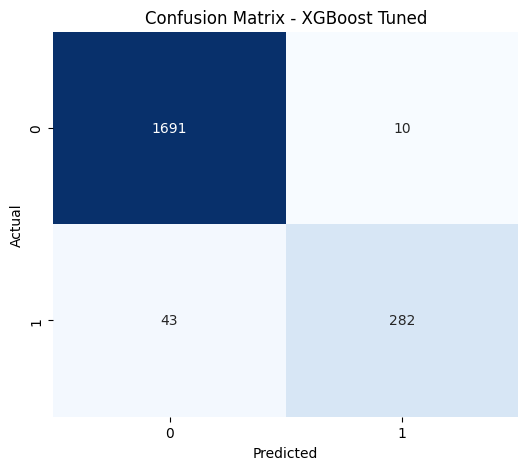

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1701
           1       0.97      0.87      0.91       325

    accuracy                           0.97      2026
   macro avg       0.97      0.93      0.95      2026
weighted avg       0.97      0.97      0.97      2026



In [ ]:
# Map nama model ke objek model yang sudah di-fit
model_dict = {
    "LogReg Baseline": model_logreg,
    "LogReg Tuned": model_tuning_logreg.best_estimator_,
    "Decision Tree Baseline": model_dt,
    "Decision Tree Tuned": model_tuning_dt.best_estimator_,
    "Random Forest Baseline": model_rf,
    "Random Forest Tuned": model_tuning_rf.best_estimator_,
    "XGBoost Baseline": model_xgboost,
    "XGBoost Tuned": model_tuning_xgboost.best_estimator_
}

best_model_name = best_model.iloc[0]['Model']
best_model_obj = model_dict[best_model_name]

# Prediksi test set
y_pred_best = best_model_obj.predict(X_test)

# Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

# Classification report
print(classification_report(y_test, y_pred_best))

## Best Model berdasarkan Kuantitatif dan Pertimbangan Bisnis

Interpretasi Komponen Confussion Matrix :
1. True Negatif (1691) : Model memprediksi 1691 pelanggan yang masih bertahan.
2. True Positive (282) : Model memprediksi 282 pelanggan yang berpotensi akan churn.
3. False Positive (10) : Model memprediksi 10 yang churn tapi sebenernya tidak churnn.
4. False Negative (43) : Model tidak dapat memprediksi pelanggan yang sebenernya churn namun terdata churn.

Interpretasi Model :
1. Model mampu memprediksi sekitar 87% pelanggan yang churn (dilihat berdasarkan recall)
2. Ketika model memprediksi pelanggan yang akan churn, sekitar 97% pelanggan yang diprediksi kemungkinan adalah benar (dilihat berdasarkan precission)

Analissi perspektif bisnis :
1. 282 pelanggan yang terdeteksi churn menjadi target utama untuk perusahaan dalam melakukan penawaran yang dapat membuat pelanggan bertahan.
2. 10 Pelanggan yang slaah diprediksi churn tidak terlalu membuat kerugian yang terlalu banyak, bahkan penawaran yang diberikan dapat membuat pelanggan menjadi semakin bertahan.
3. 43 pelanggan yang tidaj terdeteksi churn, menjadi evaluasi lebih lanjut untuk meningkatkan kemampuan model dalam mendeteksi churn.

# Analisis Interpretabilitas Model

## Analisis Model dan Feature

### Menggunakan SMOTE

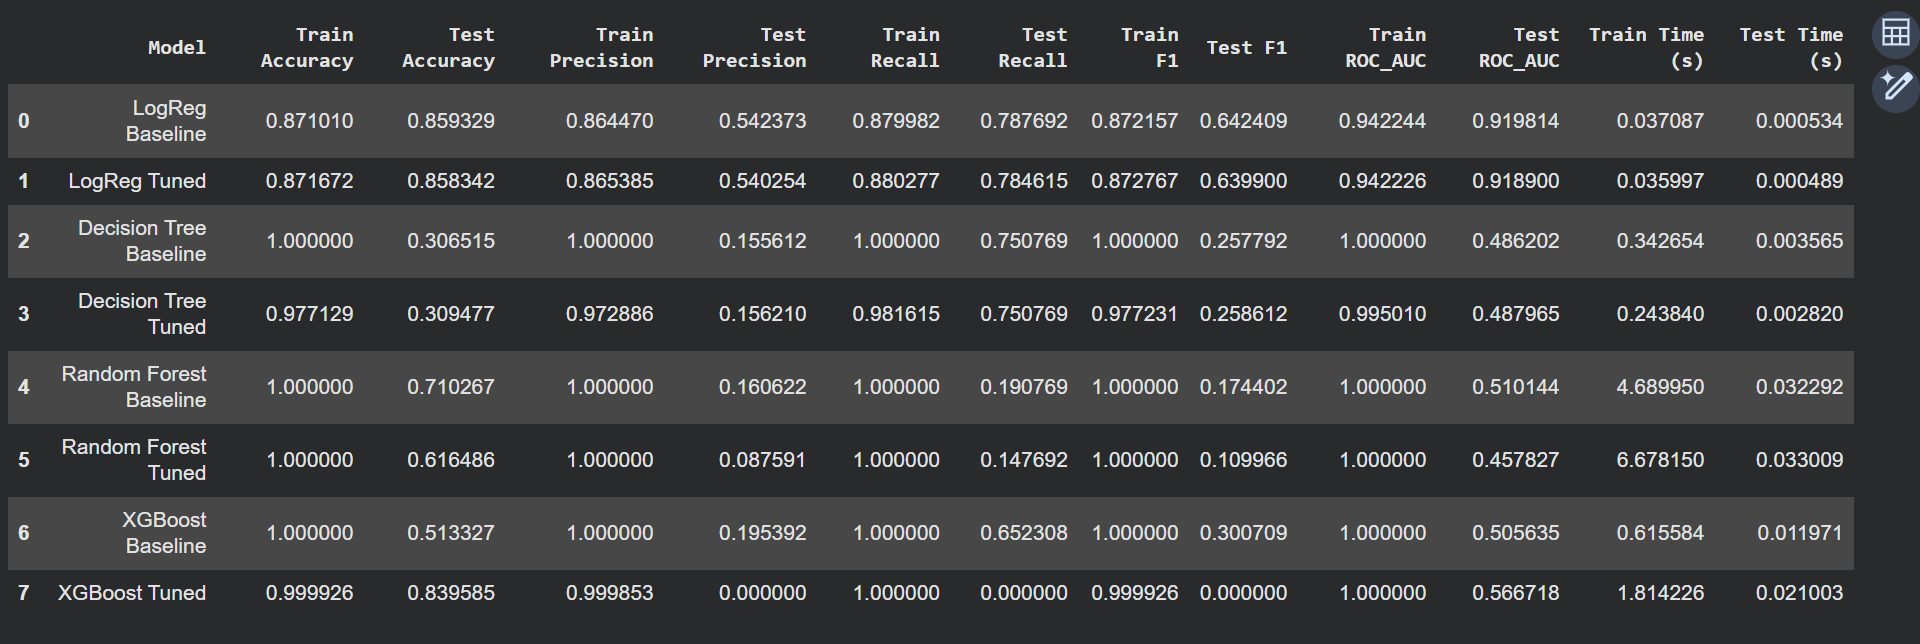

### Tanpa SMOTE

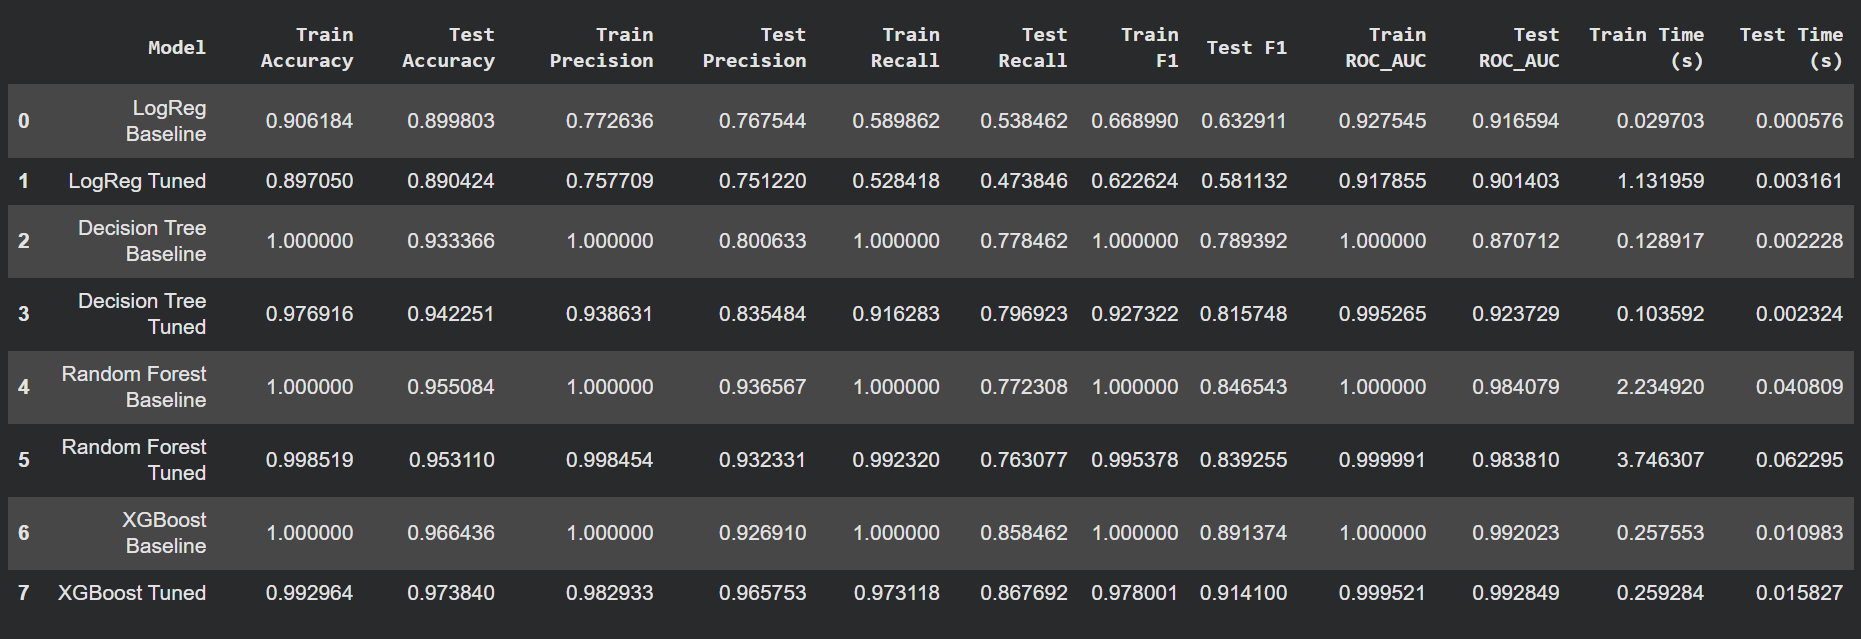

Untuk hasil evaluasi matrix dengan dan tanpa SMOTE, didapatkan bahwa yang tanpa SMOTE menghasilkan nilai yang lebih baik jika dibandingkan dengan yang menggunakan SMOTE yang menghasilkan overfitting yang sangat parah.

## Fitur paling berpengaruh terhadap Churn

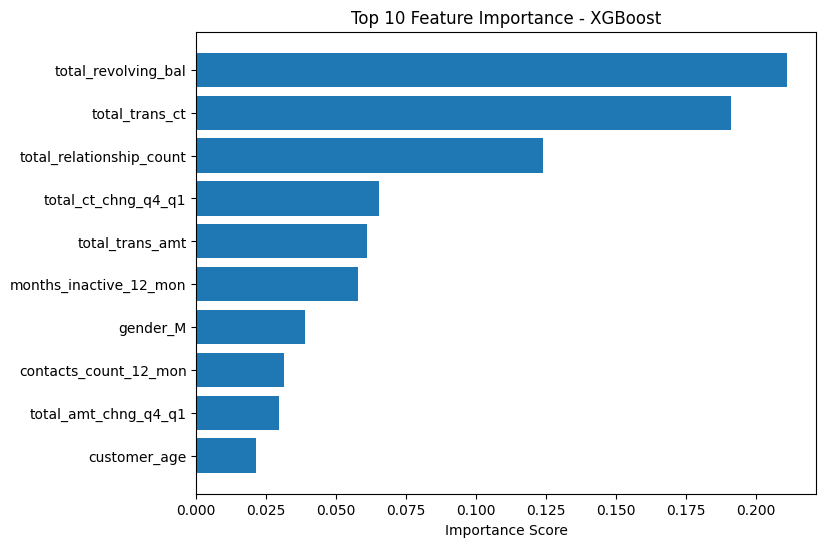

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(feature_importance['Feature'][-10:], feature_importance['Importance'][-10:])
plt.title("Top 10 Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.show()

Yang paling mempengaruhi churn berdasarkan model XGBoost dengan tuning adalah
1. Total Revolving Balance : menggambarkan jumlah saldo kredit yang belum dibayar oleh pelanggan pada periode tertentu. Nilai yang tinggi dapat mengindikasikan bahwa pelanggan memiliki beban utang yang cukup besar. Dalam beberapa kasus, dapat meningkatkan risiko churn karena pelanggan mungkin mengalami kesulitan dalam mengelola pembayaran atau memilih untuk menutup akun kartu kredit mereka.
2. Total Transaction Count : menggambarkan frekuensi transaksi yang dilakukan oleh pelanggan. Pelanggan dengan jumlah transaksi yang tinggi cenderung lebih aktif menggunakan layanan sehingga memiliki kemungkinan churn yang lebih rendah. Sebaliknya, penurunan jumlah transaksi dapat menjadi indikasi awal bahwa pelanggan mulai jarang menggunakan layanan dan berpotensi untuk berhenti.
3. Total Relationship Count : menggambarkan jumlah produk atau layanan yang dimiliki pelanggan pada bank, seperti kartu kredit yang lebih dari 1 atau layanan keuangan lainnya. Pelanggan yang memiliki lebih banyak produk/layanan biasanya memiliki keterikatan yang lebih kuat dengan bank, sehingga peluang churn menjadi lebih kecil.
4. Total Count Change Q4 Q1 : menggambarkan perubahan jumlah transaksi antara kuartal keempat dan kuartal pertama. Perubahan ini dapat menunjukkan naik turunnya perilaku pelanggan dalam menggunakan layanan. Penurunan transaksi yang signifikan dapat menjadi pertanda bahwa pelanggan mulai kehilangan minat terhadap layanan yang diberikan.
5. Total Transaction Amount : menggambarkan total nilai transaksi yang dilakukan pelanggan dalam periode tertentu. Pelanggan dengan jumlah transaksi yang tinggi cenderung lebih aktif menggunakan layanan sehingga memiliki kemungkinan churn yang lebih rendah. Sebaliknya, penurunan jumlah transaksi dapat menjadi indikasi awal bahwa pelanggan mulai jarang menggunakan layanan dan berpotensi untuk berhenti.

## Bandingkan hasil Interpretasi dengan EDA

**INTERPRETASI EDA**
1. Total Transaction Count : Memiliki frekuensi transaksi sebanyak 40-80, dimana aktivitas transaksi yang rendah.
2. Total Count Change Q4 Q1 : Memiliki Total Count Change Q4 to Q1 berada pada sekitar 0.6–0.8, dimana terdapat penurunan aktivitas transaksi.
3. Total revolving Balance : Memiliki jumlah saldo yang belum dibayar sangat rendah atau mendekati nol.
4. Contacts Count 12 Month : 2–3 kali melakukan kontak dengan bank dalam setahun.
5. Avarage Utilization Ratio : Memiliki rata-rata utilization ratio rendah, di bawah 0.2.

**INTERPRETASI HASIL MODEL XGBoost TUNING**
1. Total Revolving Balance (sekitar 0.22) : dapat meningkatkan risiko churn karena pelanggan mungkin mengalami kesulitan dalam mengelola pembayaran atau memilih untuk menutup akun kartu kredit mereka.
2. Total Transaction Count (sekitar 0.19) : menggambarkan frekuensi transaksi yang dilakukan oleh pelanggan. Penurunan jumlah transaksi dapat menjadi indikasi awal bahwa pelanggan mulai jarang menggunakan layanan dan berpotensi untuk berhenti.
3. Total Relationship Count (sekitar 0.125) : Pelanggan yang memiliki lebih banyak produk/layanan biasanya memiliki keterikatan yang lebih kuat dengan bank, sehingga peluang churn menjadi lebih kecil.
4. Total Count Change Q4 Q1 (sekitar 0.7) : Penurunan transaksi yang signifikan dapat menjadi pertanda bahwa pelanggan mulai kehilangan minat terhadap layanan yang diberikan.
5. Total Transaction Amount (sekitar 0.68) : Penurunan jumlah transaksi dapat menjadi indikasi awal bahwa pelanggan mulai jarang menggunakan layanan dan berpotensi untuk berhenti.

Hasil EDA dan model XGBoost tuning menunjukkan beberapa fitur yang sama dalam 5 besar mempengaruhi churn walau dengan letak yang berbeda. Kedua pendekatan tersebut menggambarkan aktivitas transaksi yang menurun, rendahnya pemanfaatan kredit, serta rendahnya keterikatan pelanggan dengan layanan bank merupakan indikator utama terjadinya churn. Dengan demikian, perusahaan dapat memanfaatkan informasi ini untuk merancang strategi retensi pelanggan, seperti meningkatkan engagement pelanggan yang aktivitas transaksinya mulai menurun atau menawarkan produk tambahan untuk meningkatkan keterikatan pelanggan dengan layanan bank.

# Simulasi Dampak Bisnis

Berdasarkan hasil evaluasi model terbaik (XGBoost Tuning), diperoleh:
- Recall = 87%
- Precision = 97%
- Total customer pada dataset = 10.127
- Customer churn aktual ≈ 16%

Asumsi bisnis tambahan:
- Tim retention akan menghubungi semua customer yang diprediksi churn
- Biaya retensi (voucher/promo) = Rp 50.000 per customer
- Tingkat keberhasilan retensi = 40%
- Customer Lifetime Value (CLV) rata-rata = Rp 2.000.000

## Customer berisiko tinggi berdasarkan hasil prediksi model

**Jumlah customer churn aktual:**

10.127 × 16% = 1.620


**Model dengan recall 80% mendeteksi:**

1.620 × 87% = 1.409

**Model dengan precision 97% mendeteksi:**

1409 × 97% = 1.336

model akan memprediksi 1409 yang akan churn dan yang benar-benar churn sebanyak 1336 pelanggan.

## Potensi revenue yang dapat diselamatkan jika model digunakan

**total biaaya retensi :**

1409 × 50.000 = Rp 70.450.000

**customer yang berhasil dipertahankan :**

1336 × 40% = 534 pelanggan

**potensi revenue yang diselamatkan :**
534 × Rp 2.000.000 = Rp 1.068.000.000

# Executive Summary

Perhitungan yang dilakuakn sbeelumnya bertujuan untuk mengidentifikasi faktor apa saja yang mempengaruhi churn pelanggan kartu kredit serta membangun model prediksi yang mampu mendeteksi pelanggan yang berisiko berhenti. Berdasarkan eksplorasi data dan pemodelan menggunakan beberapa model didapatkan bahwa XGBoost dengan Tuning menunjukan hasil yang terbaik jika dibandingkan dengan model yang lain. Aktivitas transaksi dan tingkat keterlibatan pelanggan menjadi faktor utama dalam mempengaruhi churn. Pelanggan yang cenderung churn sebagian besar menunjukkan aktivitas transaksi yang rendah, penurunan frekuensi transaksi dari waktu ke waktu, serta pemanfaatan kredit yang relatif rendah.

Saran : Menggunakan model yang lainnya atau menggunakan tunning yang lain agar bisa lebih melihat bagaimana pengaruhnya.

# Referensi


pengertian mengenai dataset diambil dari beberapa sumber berikut :
1. https://www.mdpi.com/1948544
2. https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers
3. https://jst.vn/index.php/ssad/article/view/82/45
4. https://cendikiaishmatuka.medium.com/bank-churn-analysis-understanding-customer-attrition-28e8cea73a86